> **Recommended Runtime**: Use a **TPU Runtime** on Google Colab for maximum performance.
>
> This notebook is optimized to use process-based parallelism (`loky`), which can leverage the high core count (e.g., 96 cores) often available in TPU runtimes.

# Precautionary Principle Analysis

This notebook explores the "Precautionary Principle" by identifying the **worst-case scenarios** (maximum death proportions) for two distinct vaccination strategies:

1.  **Vaccinate All**: Vaccinate the entire population.
2.  **Vaccinate Vulnerable Only**: Vaccinate only the high-risk (vulnerable) population.

We use Bayesian Optimization to search the parameter space for conditions that maximize deaths in each scenario.

In [1]:
import multiprocessing
print(f"Available CPU cores: {multiprocessing.cpu_count()}")

Available CPU cores: 44


## Setup and Dependencies

In [2]:
!pip install scikit-optimize

from joblib import Parallel, delayed
from multiprocessing import cpu_count
from skopt import Optimizer
from skopt.space import Real
from skopt.plots import plot_convergence
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from tqdm.notebook import tqdm

# Clone repo to get simulation classes
!git clone https://github.com/IgnacioOQ/vaccine_ethics
%cd vaccine_ethics
import sys
sys.path.append('/content/vaccine_ethics')

from agent_class import FullAgent
from simulation_class import Simulation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.5 MB/s eta 0:00:00
Cloning into 'vaccine_ethics'...
remote: Enumerating objects: 302, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 302 (delta 72), reused 78 (delta 29), pack-reused 179 (from 1)
Receiving objects: 100% (302/302), 6.72 MiB | 42.45 MiB/s, done.
Resolving deltas: 100% (167/167), done.
/content/vaccine_ethics


In [3]:
# Decide where to put the files and do the working
from google.colab import drive
drive.mount('/content/drive')

dump_path = '/content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/'
print("Current Directory:", dump_path)

# Ensure directory exists
if not os.path.exists(dump_path):
    os.makedirs(dump_path)


Mounted at /content/drive
Current Directory: /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/


## Parameters and Search Space

In [4]:
# --- Fixed Parameters ---
grid_size = 25
num_agents = 500
init_infected_proportion = 0.1
proportion_vulnerable = 0.1
recovery_time = 30
fixed_infection_prob = 0.25
fixed_immune_adaptation_effect = 0.05
fixed_vul_penalty = 2

# --- Search Space ---
space = [
    Real(0.01, 0.9, name='death_prob'),
    Real(0.1, 0.9, name='vax_effect'),
    Real(0.1, 0.9, name='viral_age_effect')
]

## Simulation Logic

We define two objective functions to **maximize deaths** (by minimizing negative deaths).
Averages metrics over `n_trials` for robustness.

In [5]:
def run_simulation_instance(params, vax_all_strategy, seed):
    """Runs a single simulation instance."""
    rngseed = random.seed(int(seed))
    nprngseed = np.random.default_rng(seed)

    simulation = Simulation(
        grid_size=grid_size,
        num_agents=num_agents,
        agent_class=FullAgent,
        init_infected_proportion=init_infected_proportion,
        proportion_vulnerable=proportion_vulnerable,
        vul_penalty=fixed_vul_penalty,
        infection_prob=fixed_infection_prob,
        recovery_time=recovery_time,
        death_prob=params[0],
        vax_vulnerable=True,  # Always true in this study context
        vax_all=vax_all_strategy,
        vax_effect=params[1],
        viral_age_effect=params[2],
        immune_adaptation_effect=fixed_immune_adaptation_effect,
        plot=False,
        rngseed=rngseed,
        nprngseed=nprngseed,
        seed=seed
    )
    simulation.run()
    return simulation.generate_simulation_report()[1]  # Return death_proportion

def average_death_proportion(params, vax_all_strategy, n_trials=200):
    """Returns averaged death proportion over n_trials."""
    ss = np.random.SeedSequence()
    seeds = ss.generate_state(n_trials, dtype=np.uint32)

    deaths = Parallel(n_jobs=min(cpu_count(), n_trials))(
        delayed(run_simulation_instance)(params, vax_all_strategy, seed) for seed in seeds
    )
    return np.mean(deaths)

# --- Objective Functions for Optimization ---
# We want to MAXIMIZE deaths, so we MINIMIZE (-1 * deaths)

def objective_vax_all(params):
    return -average_death_proportion(params, vax_all_strategy=True)

def objective_vax_vuln_only(params):
    return -average_death_proportion(params, vax_all_strategy=False)

## Bayesian Optimization Searches

1. Find Worst Case for **Vaccinate All**
2. Find Worst Case for **Vaccinate Vulnerable Only**

In [6]:
n_calls = 1000
n_initial_points = 100

print("--- Searching for Worst Case: VACCINATE ALL ---")
opt_vax_all = Optimizer(space, base_estimator="GP", acq_func="EI", n_initial_points=n_initial_points)

for i in tqdm(range(n_calls)):
    next_x = opt_vax_all.ask()
    f_val = objective_vax_all(next_x)
    opt_vax_all.tell(next_x, f_val)

res_vax_all = opt_vax_all.get_result()
worst_death_prop_vax_all = -res_vax_all.fun
worst_params_vax_all = res_vax_all.x

print(f"Worst Case (Vax All) Death Proportion: {worst_death_prop_vax_all:.4f}")
print(f"Parameters: death_prob={worst_params_vax_all[0]:.2f}, vax_effect={worst_params_vax_all[1]:.2f}, viral_age_effect={worst_params_vax_all[2]:.2f}")

--- Searching for Worst Case: VACCINATE ALL ---


  0%|          | 0/1000 [00:00<?, ?it/s]

Worst Case (Vax All) Death Proportion: 0.4671
Parameters: death_prob=0.09, vax_effect=0.10, viral_age_effect=0.10


In [7]:
print("\n--- Searching for Worst Case: VACCINATE VULNERABLE ONLY ---")
opt_vax_vuln = Optimizer(space, base_estimator="GP", acq_func="EI", n_initial_points=n_initial_points)

for i in tqdm(range(n_calls)):
    next_x = opt_vax_vuln.ask()
    f_val = objective_vax_vuln_only(next_x)
    opt_vax_vuln.tell(next_x, f_val)

res_vax_vuln = opt_vax_vuln.get_result()
worst_death_prop_vax_vuln = -res_vax_vuln.fun
worst_params_vax_vuln = res_vax_vuln.x

print(f"Worst Case (Vax Vuln Only) Death Proportion: {worst_death_prop_vax_vuln:.4f}")
print(f"Parameters: death_prob={worst_params_vax_vuln[0]:.2f}, vax_effect={worst_params_vax_vuln[1]:.2f}, viral_age_effect={worst_params_vax_vuln[2]:.2f}")


--- Searching for Worst Case: VACCINATE VULNERABLE ONLY ---


  0%|          | 0/1000 [00:00<?, ?it/s]

Worst Case (Vax Vuln Only) Death Proportion: 0.5629
Parameters: death_prob=0.07, vax_effect=0.12, viral_age_effect=0.10


## Analysis and Comparison

Compare the worst-case outcomes to determine the safer precautionary strategy.

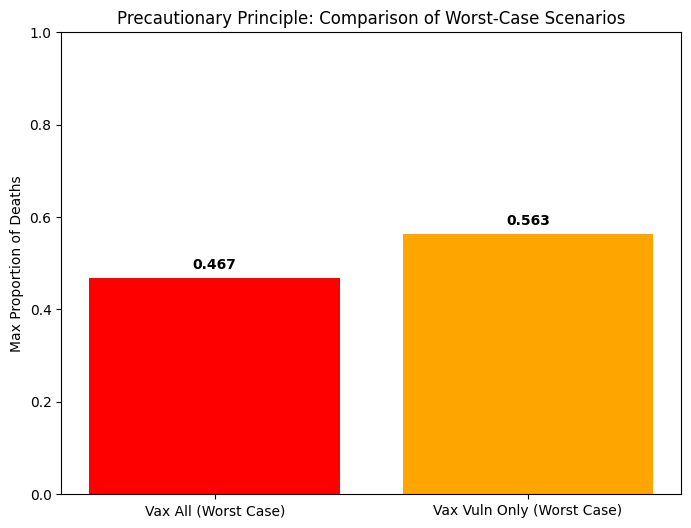

CONCLUSION: 'Vaccinate All' is the safer precautionary strategy (lower worst-case deaths).


In [ ]:
labels = ['Vax All (Worst Case)', 'Vax Vuln Only (Worst Case)']
values = [worst_death_prop_vax_all, worst_death_prop_vax_vuln]

plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['red', 'orange'])
plt.ylabel('Max Proportion of Deaths')
plt.title('Precautionary Principle: Comparison of Worst-Case Scenarios')
plt.ylim(0, 1.0)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()

if worst_death_prop_vax_all < worst_death_prop_vax_vuln:
    print("CONCLUSION: 'Vaccinate All' is the safer precautionary strategy (lower worst-case deaths).")
else:
    print("CONCLUSION: 'Vaccinate Vulnerable Only' is the safer precautionary strategy (lower worst-case deaths).")

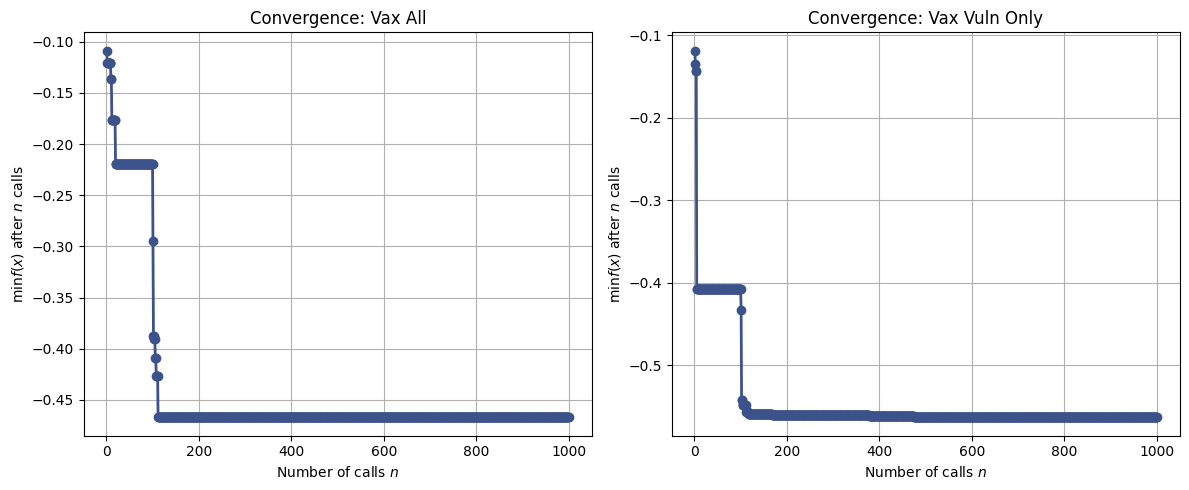

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_convergence(res_vax_all)
plt.title('Convergence: Vax All')

plt.subplot(1, 2, 2)
plot_convergence(res_vax_vuln)
plt.title('Convergence: Vax Vuln Only')
plt.tight_layout()
plt.show()

In [10]:
# Save results to CSV/Text
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
filename = f"{dump_path}precautionary_analysis_{timestamp}.txt"

with open(filename, "w") as f:
    f.write("Precautionary Principle Analysis Results\n")
    f.write("========================================\n\n")
    f.write(f"Vaccinate All - Worst Case Death Proportion: {worst_death_prop_vax_all:.4f}\n")
    f.write(f"Parameters: {worst_params_vax_all}\n\n")
    f.write(f"Vaccinate Vulnerable Only - Worst Case Death Proportion: {worst_death_prop_vax_vuln:.4f}\n")
    f.write(f"Parameters: {worst_params_vax_vuln}\n\n")

    if worst_death_prop_vax_all < worst_death_prop_vax_vuln:
        f.write("CONCLUSION: 'Vaccinate All' is the safer precautionary strategy.\n")
    else:
        f.write("CONCLUSION: 'Vaccinate Vulnerable Only' is the safer precautionary strategy.\n")

print(f"Results saved to {filename}")

Results saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/precautionary_analysis_20260218-125831.txt


# Disconnect from Runtime

In [11]:
from datetime import datetime
import pytz
from IPython.display import Javascript

# Get current time in New York
nyc_time = datetime.now(pytz.timezone('America/New_York'))
formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# Print and log
print(f"✅ Disconnected from runtime at: {formatted_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2026-02-18 07:58:32 EST


<IPython.core.display.Javascript object>